# KLA Semiconductor Hackathon Colab Training Code

In [24]:
# CELL 1 — Mount Google Drive to avoid repeated downloading of the given dataset. Skip if the dataset is already available

from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT = "/content/drive/MyDrive/KLA_Semicon_Hackathon"

RUN_NAME = "stable_fast_fp16_50epoch"

RUN_DIR = os.path.join(
    DRIVE_ROOT,
    RUN_NAME
)

os.makedirs(
    RUN_DIR,
    exist_ok=True
)

print("Drive root:", DRIVE_ROOT)
print("Run folder:", RUN_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/KLA_Semicon_Hackathon
Run folder: /content/drive/MyDrive/KLA_Semicon_Hackathon/stable_fast_fp16_50epoch


In [2]:
# CELL 2 — Install required packages

!pip -q install -U gdown pytorch-msssim lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00


In [3]:
# CELL 3 — Download dataset if needed

import os
import glob
import gdown

DATASET_URL = "https://drive.google.com/drive/folders/1VKiFW-kDk9-q5XRPu3nrl08OM94EwzV6"

DOWNLOAD_DIR = os.path.join(
    DRIVE_ROOT,
    "downloaded_dataset"
)

os.makedirs(
    DOWNLOAD_DIR,
    exist_ok=True
)

zip_files = glob.glob(
    os.path.join(
        DOWNLOAD_DIR,
        "**",
        "*.zip"
    ),
    recursive=True
)

if len(zip_files) >= 2:

    print("Dataset ZIP files already exist.")
    print("Skipping download.")

    for z in zip_files:
        print(" -", z)

else:

    print("Downloading KLA dataset...")

    gdown.download_folder(
        url=DATASET_URL,
        output=DOWNLOAD_DIR,
        quiet=False,
        use_cookies=False
    )

    print("Download complete.")

Dataset ZIP files already exist.
Skipping download.
 - /content/drive/MyDrive/KLA_Semicon_Hackathon/downloaded_dataset/Test_NoisyLR.zip
 - /content/drive/MyDrive/KLA_Semicon_Hackathon/downloaded_dataset/train.zip


In [4]:
# CELL 4 — Extract dataset to Colab local SSD

import os
import glob
import zipfile
import shutil

LOCAL_ROOT = "/content/kla_dataset"

if os.path.exists(LOCAL_ROOT):
    shutil.rmtree(LOCAL_ROOT)

os.makedirs(
    LOCAL_ROOT,
    exist_ok=True
)

zip_files = glob.glob(
    os.path.join(
        DOWNLOAD_DIR,
        "**",
        "*.zip"
    ),
    recursive=True
)

for zip_path in zip_files:

    name = os.path.basename(
        zip_path
    ).lower()

    if name == "train.zip":

        extract_to = os.path.join(
            LOCAL_ROOT,
            "train"
        )

    elif name == "test_noisylr.zip":

        extract_to = os.path.join(
            LOCAL_ROOT,
            "Test_NoisyLR"
        )

    else:

        continue

    os.makedirs(
        extract_to,
        exist_ok=True
    )

    print("Extracting:", os.path.basename(zip_path))

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zf:

        zf.extractall(
            extract_to
        )

# Remove macOS metadata
for root, dirs, files in os.walk(
    LOCAL_ROOT,
    topdown=False
):

    for d in dirs:

        if d == "__MACOSX":

            shutil.rmtree(
                os.path.join(root, d),
                ignore_errors=True
            )

    for f in files:

        if f == ".DS_Store":

            try:
                os.remove(
                    os.path.join(root, f)
                )

            except FileNotFoundError:
                pass

print("Extraction complete.")

Extracting: Test_NoisyLR.zip
Extracting: train.zip
Extraction complete.


In [5]:
# CELL 5 — Verify dataset

import os
import glob
from pathlib import Path
import numpy as np

GT_DIR = os.path.join(
    LOCAL_ROOT,
    "train",
    "train",
    "GT"
)

TRAIN_LR_DIR = os.path.join(
    LOCAL_ROOT,
    "train",
    "train",
    "NoisyLR"
)

TEST_LR_DIR = os.path.join(
    LOCAL_ROOT,
    "Test_NoisyLR",
    "NoisyLR"
)

gt_files = sorted(
    glob.glob(
        os.path.join(
            GT_DIR,
            "*.npy"
        )
    )
)

lr_files = sorted(
    glob.glob(
        os.path.join(
            TRAIN_LR_DIR,
            "*.npy"
        )
    )
)

test_files = sorted(
    glob.glob(
        os.path.join(
            TEST_LR_DIR,
            "*.npy"
        )
    )
)

print("GT files       :", len(gt_files))
print("Training LR    :", len(lr_files))
print("Test LR        :", len(test_files))

assert len(gt_files) == 3200
assert len(lr_files) == 3200
assert len(test_files) == 400

assert [
    Path(x).name
    for x in gt_files
] == [
    Path(x).name
    for x in lr_files
]

lr0 = np.load(
    lr_files[0],
    allow_pickle=False
)

gt0 = np.load(
    gt_files[0],
    allow_pickle=False
)

assert lr0.shape == (128,128)
assert gt0.shape == (256,256)
assert lr0.dtype == np.float32
assert gt0.dtype == np.float32

print()
print("LR:", lr0.shape, lr0.dtype, float(lr0.min()), float(lr0.max()))
print("GT:", gt0.shape, gt0.dtype, float(gt0.min()), float(gt0.max()))
print()
print("Dataset verification PASSED.")

GT files       : 3200
Training LR    : 3200
Test LR        : 400

LR: (128, 128) float32 -0.0026427102275192738 1.3257757425308228
GT: (256, 256) float32 0.0 1.0

Dataset verification PASSED.


In [6]:
# CELL 6 — Imports, reproducibility and stable CUDA configuration

import math
import time
import random
import json
import csv

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim

SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = False

if torch.cuda.is_available():

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

torch.set_float32_matmul_precision(
    "high"
)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("cuDNN   :", torch.backends.cudnn.version())
print("Device  :", device)
print("cuDNN benchmark:", torch.backends.cudnn.benchmark)

if device.type == "cuda":

    props = torch.cuda.get_device_properties(0)

    print("GPU     :", torch.cuda.get_device_name(0))
    print("VRAM GB :", props.total_memory/(1024**3))

print()
print("Training mode: FP16 AMP + GradScaler")

PyTorch : 2.11.0+cu128
CUDA    : 12.8
cuDNN   : 91900
Device  : cuda
cuDNN benchmark: False
GPU     : Tesla T4
VRAM GB : 14.56317138671875

Training mode: FP16 AMP + GradScaler


In [7]:
# CELL 7 — Dataset class and fixed 90/10 split

class KLAPairedDataset(Dataset):

    def __init__(
        self,
        lr_files,
        gt_files,
        train=True,
        patch=96
    ):

        self.lr_files = list(lr_files)
        self.gt_files = list(gt_files)

        self.train = train
        self.patch = patch

    def __len__(self):

        return len(
            self.lr_files
        )

    def __getitem__(self, i):

        lr = np.load(
            self.lr_files[i],
            allow_pickle=False
        ).astype(
            np.float32,
            copy=False
        )

        gt = np.load(
            self.gt_files[i],
            allow_pickle=False
        ).astype(
            np.float32,
            copy=False
        )

        if self.train and self.patch < 128:

            p = self.patch

            top = np.random.randint(
                0,
                128-p+1
            )

            left = np.random.randint(
                0,
                128-p+1
            )

            lr = lr[
                top:top+p,
                left:left+p
            ]

            gt = gt[
                2*top:2*(top+p),
                2*left:2*(left+p)
            ]

        if self.train:

            k = np.random.randint(
                0,
                4
            )

            lr = np.rot90(
                lr,
                k
            )

            gt = np.rot90(
                gt,
                k
            )

            if np.random.rand() < 0.5:

                lr = np.fliplr(
                    lr
                )

                gt = np.fliplr(
                    gt
                )

            if np.random.rand() < 0.5:

                lr = np.flipud(
                    lr
                )

                gt = np.flipud(
                    gt
                )

        lr = np.ascontiguousarray(
            lr
        )

        gt = np.ascontiguousarray(
            gt
        )

        return (
            torch.from_numpy(
                lr
            ).unsqueeze(0),

            torch.from_numpy(
                gt
            ).unsqueeze(0)
        )


indices = np.arange(
    len(lr_files)
)

rng = np.random.default_rng(
    SEED
)

rng.shuffle(
    indices
)

N_VAL = 320

val_idx = indices[
    :N_VAL
]

train_idx = indices[
    N_VAL:
]

train_lr = [
    lr_files[i]
    for i in train_idx
]

train_gt = [
    gt_files[i]
    for i in train_idx
]

val_lr = [
    lr_files[i]
    for i in val_idx
]

val_gt = [
    gt_files[i]
    for i in val_idx
]

print("Training samples  :", len(train_lr))
print("Validation samples:", len(val_lr))

Training samples  : 2880
Validation samples: 320


In [8]:
# CELL 8 — FastNAF-SR model

class LayerNorm2d(nn.Module):

    def __init__(
        self,
        channels,
        eps=1e-6
    ):

        super().__init__()

        self.weight = nn.Parameter(
            torch.ones(
                1,
                channels,
                1,
                1
            )
        )

        self.bias = nn.Parameter(
            torch.zeros(
                1,
                channels,
                1,
                1
            )
        )

        self.eps = eps

    def forward(self, x):

        dtype = x.dtype

        # FP32 normalization statistics
        xf = x.float()

        mean = xf.mean(
            dim=1,
            keepdim=True
        )

        var = (
            (xf-mean)
            .square()
            .mean(
                dim=1,
                keepdim=True
            )
        )

        y = (
            (xf-mean)
            * torch.rsqrt(
                var+self.eps
            )
        )

        y = y.to(
            dtype
        )

        return (
            y*self.weight.to(dtype)
            + self.bias.to(dtype)
        )


class SimpleGate(nn.Module):

    def forward(self, x):

        a,b = x.chunk(
            2,
            dim=1
        )

        return a*b


class FastNAFBlock(nn.Module):

    def __init__(
        self,
        c,
        dw_expand=2,
        ffn_expand=2
    ):

        super().__init__()

        dw = c*dw_expand
        ffn = c*ffn_expand

        self.norm1 = LayerNorm2d(
            c
        )

        self.pw1 = nn.Conv2d(
            c,
            dw,
            1
        )

        self.dw = nn.Conv2d(
            dw,
            dw,
            3,
            padding=1,
            groups=dw
        )

        self.sg1 = SimpleGate()

        gated = dw//2

        self.pool = nn.AdaptiveAvgPool2d(
            1
        )

        self.sca = nn.Conv2d(
            gated,
            gated,
            1
        )

        self.pw2 = nn.Conv2d(
            gated,
            c,
            1
        )

        self.norm2 = LayerNorm2d(
            c
        )

        self.ffn1 = nn.Conv2d(
            c,
            ffn,
            1
        )

        self.sg2 = SimpleGate()

        self.ffn2 = nn.Conv2d(
            ffn//2,
            c,
            1
        )

        self.beta = nn.Parameter(
            torch.zeros(
                1,
                c,
                1,
                1
            )
        )

        self.gamma = nn.Parameter(
            torch.zeros(
                1,
                c,
                1,
                1
            )
        )

    def forward(self, x):

        y = self.norm1(
            x
        )

        y = self.pw1(
            y
        )

        y = self.dw(
            y
        )

        y = self.sg1(
            y
        )

        y = y*self.sca(
            self.pool(y)
        )

        y = self.pw2(
            y
        )

        x = x+self.beta*y

        y = self.norm2(
            x
        )

        y = self.ffn1(
            y
        )

        y = self.sg2(
            y
        )

        y = self.ffn2(
            y
        )

        return x+self.gamma*y


class FastNAFSR(nn.Module):

    def __init__(
        self,
        width=64,
        blocks=12,
        scale=2
    ):

        super().__init__()

        self.scale = scale

        self.intro = nn.Conv2d(
            1,
            width,
            3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                FastNAFBlock(
                    width
                )
                for _ in range(
                    blocks
                )
            ]
        )

        self.up = nn.Conv2d(
            width,
            scale*scale,
            3,
            padding=1
        )

        self.shuffle = nn.PixelShuffle(
            scale
        )

        nn.init.zeros_(
            self.up.weight
        )

        nn.init.zeros_(
            self.up.bias
        )

    def forward(self, x):

        base = F.interpolate(
            x.clamp(
                0,
                1
            ),
            scale_factor=self.scale,
            mode="bicubic",
            align_corners=False
        )

        # learned branch sees raw LR values
        f = self.intro(
            x
        )

        f = self.body(
            f
        )

        residual = self.shuffle(
            self.up(
                f
            )
        )

        return base+residual


MODEL_CFG = {
    "width":64,
    "blocks":12,
    "scale":2
}

model = FastNAFSR(
    **MODEL_CFG
).to(
    device
)

params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", f"{params:,}")
print("Model size :", f"{params/1e6:.3f} M parameters")

with torch.no_grad():

    dummy = torch.randn(
        2,
        1,
        128,
        128,
        device=device
    )

    output = model(
        dummy
    )

print(
    "Shape test:",
    tuple(dummy.shape),
    "->",
    tuple(output.shape)
)

Parameters: 372,356
Model size : 0.372 M parameters
Shape test: (2, 1, 128, 128) -> (2, 1, 256, 256)


In [9]:
# CELL 9 — FP16 forward/backward smoke test

print("Running FP16 smoke test...")

model.train()

x = torch.randn(
    4,
    1,
    96,
    96,
    device=device,
    dtype=torch.float32
)

target = torch.rand(
    4,
    1,
    192,
    192,
    device=device,
    dtype=torch.float32
)

test_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

test_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type=="cuda"),
    init_scale=512,
    growth_interval=4000
)

test_optimizer.zero_grad(
    set_to_none=True
)

if device.type == "cuda":

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        pred = model(
            x
        )

        test_loss = F.mse_loss(
            pred.float(),
            target
        )

else:

    pred = model(
        x
    )

    test_loss = F.mse_loss(
        pred,
        target
    )

test_scaler.scale(
    test_loss
).backward()

test_scaler.unscale_(
    test_optimizer
)

grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    0.5
)

scale_before = test_scaler.get_scale()

test_scaler.step(
    test_optimizer
)

test_scaler.update()

scale_after = test_scaler.get_scale()

print("Loss          :", float(test_loss.detach()))
print("Grad norm     :", float(grad_norm))
print("Scale before  :", scale_before)
print("Scale after   :", scale_after)
print("Optimizer step:", scale_after >= scale_before)
print()
print("FP16 SMOKE TEST COMPLETED.")

# Reinitialize a completely clean training model
model = FastNAFSR(
    **MODEL_CFG
).to(
    device
)

Running FP16 smoke test...
Loss          : 0.23341552913188934
Grad norm     : 1.5404348373413086
Scale before  : 512.0
Scale after   : 512.0
Optimizer step: True

FP16 SMOKE TEST COMPLETED.


In [10]:
# CELL 10 — Mild synthetic OOD degradation

def gaussian_kernel2d(
    sigma,
    device
):

    sigma = float(
        max(
            0.15,
            sigma
        )
    )

    radius = 2

    x = torch.arange(
        -radius,
        radius+1,
        device=device,
        dtype=torch.float32
    )

    k = torch.exp(
        -(x*x)
        /(2*sigma*sigma)
    )

    k = k/k.sum()

    return torch.outer(
        k,
        k
    )[None,None]


@torch.no_grad()
def make_synthetic_lr(
    gt
):

    b = gt.shape[0]

    sigma = float(
        torch.empty(1)
        .uniform_(
            0.25,
            0.90
        )
        .item()
    )

    kernel = gaussian_kernel2d(
        sigma,
        gt.device
    )

    x = F.conv2d(
        gt.float(),
        kernel,
        padding=2
    )

    x = F.interpolate(
        x,
        scale_factor=0.5,
        mode="bicubic",
        align_corners=False,
        antialias=True
    )

    gaussian_sigma = torch.empty(
        b,
        1,
        1,
        1,
        device=x.device
    ).uniform_(
        0.0,
        0.020
    )

    speckle_sigma = torch.empty(
        b,
        1,
        1,
        1,
        device=x.device
    ).uniform_(
        0.0,
        0.09
    )

    x = (
        x
        + torch.randn_like(x)
        * gaussian_sigma
    )

    x = (
        x
        + x
        * torch.randn_like(x)
        * speckle_sigma
    )

    gain = torch.empty(
        b,
        1,
        1,
        1,
        device=x.device
    ).uniform_(
        0.98,
        1.02
    )

    bias = torch.empty(
        b,
        1,
        1,
        1,
        device=x.device
    ).uniform_(
        -0.008,
        0.008
    )

    return x*gain+bias

In [11]:
# CELL 11 — Two-phase restoration loss

def charbonnier(
    pred,
    target,
    eps=1e-3
):

    return torch.sqrt(
        (pred-target).square()
        +eps*eps
    ).mean()


SOBEL_X = torch.tensor(
    [
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ],
    dtype=torch.float32
)[None,None]

SOBEL_Y = SOBEL_X.transpose(
    -1,
    -2
).contiguous()


def edge_loss(
    pred,
    target
):

    kx = SOBEL_X.to(
        pred.device
    )

    ky = SOBEL_Y.to(
        pred.device
    )

    p = pred.float()
    t = target.float()

    return (
        F.l1_loss(
            F.conv2d(
                p,
                kx,
                padding=1
            ),
            F.conv2d(
                t,
                kx,
                padding=1
            )
        )
        +
        F.l1_loss(
            F.conv2d(
                p,
                ky,
                padding=1
            ),
            F.conv2d(
                t,
                ky,
                padding=1
            )
        )
    )


def restoration_loss(
    pred,
    target,
    phase
):

    p = pred.float()
    t = target.float()

    mse = F.mse_loss(
        p,
        t
    )

    charb = charbonnier(
        p,
        t
    )

    ssim_loss = (
        1.0
        -ssim(
            p.clamp(
                0,
                1
            ),
            t,
            data_range=1.0,
            size_average=True
        )
    )

    edge = edge_loss(
        p,
        t
    )

    if phase == 1:

        total = (
            0.50*mse
            +0.32*charb
            +0.13*ssim_loss
            +0.05*edge
        )

    else:

        total = (
            0.72*mse
            +0.18*charb
            +0.08*ssim_loss
            +0.02*edge
        )

    return total

In [12]:
# CELL 12 — DataLoaders

PATCH = 96

if device.type == "cuda":

    gpu_gb = (
        torch.cuda
        .get_device_properties(0)
        .total_memory
        /(1024**3)
    )

else:

    gpu_gb = 0

if gpu_gb >= 35:

    BATCH = 64

elif gpu_gb >= 20:

    BATCH = 32

elif gpu_gb >= 14:

    BATCH = 24

else:

    BATCH = 16

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

train_ds = KLAPairedDataset(
    train_lr,
    train_gt,
    train=True,
    patch=PATCH
)

val_ds = KLAPairedDataset(
    val_lr,
    val_gt,
    train=False,
    patch=128
)

train_kwargs = dict(
    dataset=train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type=="cuda"),
    drop_last=True
)

val_kwargs = dict(
    dataset=val_ds,
    batch_size=max(1,BATCH//2),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type=="cuda")
)

if NUM_WORKERS > 0:

    train_kwargs["persistent_workers"] = True
    train_kwargs["prefetch_factor"] = 2

    val_kwargs["persistent_workers"] = True
    val_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    **train_kwargs
)

val_loader = DataLoader(
    **val_kwargs
)

print("GPU memory GB:", gpu_gb)
print("Batch size   :", BATCH)
print("Patch        :", PATCH)
print("Workers      :", NUM_WORKERS)
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

GPU memory GB: 14.56317138671875
Batch size   : 24
Patch        : 96
Workers      : 2
Train batches: 120
Val batches  : 27


In [13]:
# CELL 13 — EMA, PSNR and FP32 validation

class EMA:

    def __init__(
        self,
        model,
        decay=0.9995
    ):

        self.decay = decay

        self.shadow = {
            k:v.detach().clone()
            for k,v
            in model.state_dict().items()
        }

    @torch.no_grad()
    def update(
        self,
        model
    ):

        current = model.state_dict()

        for k,v in self.shadow.items():

            src = current[k].detach()

            if not torch.is_floating_point(
                v
            ):

                v.copy_(
                    src
                )

            else:

                v.mul_(
                    self.decay
                ).add_(
                    src,
                    alpha=1.0-self.decay
                )

    def copy_to(
        self,
        model
    ):

        model.load_state_dict(
            self.shadow,
            strict=True
        )


def psnr_batch(
    pred,
    target
):

    pred = pred.float().clamp(
        0,
        1
    )

    target = target.float()

    mse = (
        (pred-target)
        .square()
        .flatten(1)
        .mean(1)
        .clamp_min(
            1e-12
        )
    )

    return (
        10.0
        *torch.log10(
            1.0/mse
        )
    ).mean()


@torch.no_grad()
def validate_fp32(
    eval_model,
    loader
):

    eval_model.eval()

    psnr_sum = 0.0
    ssim_sum = 0.0
    count = 0

    for lr,gt in loader:

        lr = lr.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        # validation deliberately FP32
        pred = eval_model(
            lr
        )

        pred = pred.clamp(
            0,
            1
        )

        b = lr.shape[0]

        psnr_sum += (
            float(
                psnr_batch(
                    pred,
                    gt
                )
            )*b
        )

        ssim_sum += (
            float(
                ssim(
                    pred,
                    gt,
                    data_range=1.0,
                    size_average=True
                )
            )*b
        )

        count += b

    return (
        psnr_sum/count,
        ssim_sum/count
    )

In [14]:
# CELL 14 — Stable fast optimizer, LR schedule and GradScaler

EPOCHS = 50
PHASE1_END = 40

PEAK_LR = 3.0e-4
PHASE1_END_LR = 5.0e-5
FINAL_LR = 1.0e-5

WARMUP_EPOCHS = 3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=PEAK_LR,
    betas=(0.9,0.99),
    weight_decay=1e-4
)

steps_per_epoch = len(
    train_loader
)

warmup_steps = (
    WARMUP_EPOCHS
    *steps_per_epoch
)

phase1_end_steps = (
    PHASE1_END
    *steps_per_epoch
)

total_steps = (
    EPOCHS
    *steps_per_epoch
)

phase1_min_factor = (
    PHASE1_END_LR
    /PEAK_LR
)

final_factor = (
    FINAL_LR
    /PEAK_LR
)


def lr_lambda(
    step
):

    if step < warmup_steps:

        progress = (
            (step+1)
            /warmup_steps
        )

        return (
            0.10
            +0.90*progress
        )

    if step < phase1_end_steps:

        progress = (
            step-warmup_steps
        ) / max(
            1,
            phase1_end_steps-warmup_steps
        )

        cosine = (
            0.5
            *(
                1.0
                +math.cos(
                    math.pi*progress
                )
            )
        )

        return (
            phase1_min_factor
            +(1.0-phase1_min_factor)
            *cosine
        )

    progress = (
        step-phase1_end_steps
    ) / max(
        1,
        total_steps-phase1_end_steps
    )

    progress = min(
        1.0,
        max(
            0.0,
            progress
        )
    )

    cosine = (
        0.5
        *(
            1.0
            +math.cos(
                math.pi*progress
            )
        )
    )

    return (
        final_factor
        +(phase1_min_factor-final_factor)
        *cosine
    )


scheduler = (
    torch.optim
    .lr_scheduler
    .LambdaLR(
        optimizer,
        lr_lambda
    )
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type=="cuda"),
    init_scale=512,
    growth_factor=2.0,
    backoff_factor=0.5,
    growth_interval=4000
)

ema = EMA(
    model,
    decay=0.9995
)

print("Peak LR           :", PEAK_LR)
print("Epoch-40 target LR:", PHASE1_END_LR)
print("Final target LR   :", FINAL_LR)
print("Warm-up epochs    :", WARMUP_EPOCHS)
print("Initial scale     :", scaler.get_scale())

Peak LR           : 0.0003
Epoch-40 target LR: 5e-05
Final target LR   : 1e-05
Warm-up epochs    : 3
Initial scale     : 512


In [15]:
# CELL 15 — Safe checkpointing and automatic resume

BEST_PSNR_PATH = os.path.join(
    RUN_DIR,
    "best_psnr.pt"
)

BEST_SSIM_PATH = os.path.join(
    RUN_DIR,
    "best_ssim.pt"
)

LAST_GOOD_PATH = os.path.join(
    RUN_DIR,
    "last_good_checkpoint.pt"
)

HISTORY_PATH = os.path.join(
    RUN_DIR,
    "history.json"
)

MILESTONE_EPOCHS = {
    5,
    10,
    20,
    30,
    40,
    45,
    50
}

RESUME_IF_AVAILABLE = True

start_epoch = 1
best_psnr = -float("inf")
best_ssim = -float("inf")
history = []

if (
    RESUME_IF_AVAILABLE
    and os.path.exists(
        LAST_GOOD_PATH
    )
):

    ckpt = torch.load(
        LAST_GOOD_PATH,
        map_location="cpu",
        weights_only=False
    )

    model.load_state_dict(
        ckpt["model"],
        strict=True
    )

    optimizer.load_state_dict(
        ckpt["optimizer"]
    )

    scheduler.load_state_dict(
        ckpt["scheduler"]
    )

    scaler.load_state_dict(
        ckpt["scaler"]
    )

    ema.shadow = {
        k:v.clone()
        for k,v
        in ckpt["ema"].items()
    }

    best_psnr = ckpt["best_psnr"]
    best_ssim = ckpt["best_ssim"]

    history = ckpt.get(
        "history",
        []
    )

    start_epoch = (
        ckpt["epoch"]
        +1
    )

    print(
        "Resuming from verified-good epoch:",
        start_epoch
    )

else:

    print(
        "Starting fresh stable-fast FP16 run."
    )

Resuming from verified-good epoch: 30


In [ ]:
# CELL 16 — Stable Fast FP16 training loop

MAX_SKIPS_PER_EPOCH = 12
MAX_CONSECUTIVE_SKIPS = 6

for epoch in range(
    start_epoch,
    EPOCHS+1
):

    model.train()

    phase = (
        1
        if epoch <= PHASE1_END
        else 2
    )

    running_loss = 0.0
    successful_steps = 0
    skipped_steps = 0
    consecutive_skips = 0

    t0 = time.time()

    for batch_idx,(lr,gt) in enumerate(
        train_loader
    ):

        lr = lr.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        # ------------------------------------------------
        # Mild OOD augmentation
        # ------------------------------------------------
        #
        # Epochs 1-5: real KLA data only
        # Epochs 6-40: mild OOD augmentation
        # Epochs 41-50: real KLA data only

        if (
            6 <= epoch <= 40
            and torch.rand(
                ()
            ).item() < 0.15
        ):

            synthetic_lr = (
                make_synthetic_lr(
                    gt
                )
            )

            mask = (
                torch.rand(
                    lr.shape[0],
                    1,
                    1,
                    1,
                    device=device
                )
                <0.25
            )

            lr = torch.where(
                mask,
                synthetic_lr.to(
                    lr.dtype
                ),
                lr
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ------------------------------------------------
        # FP16 forward
        # ------------------------------------------------

        if device.type == "cuda":

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                pred = model(
                    lr
                )

                loss = restoration_loss(
                    pred,
                    gt,
                    phase
                )

        else:

            pred = model(
                lr
            )

            loss = restoration_loss(
                pred,
                gt,
                phase
            )

        # ------------------------------------------------
        # Backward
        # ------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=0.5
        )

        scale_before = scaler.get_scale()

        scaler.step(
            optimizer
        )

        scaler.update()

        scale_after = scaler.get_scale()

        optimizer_step_happened = (
            scale_after >= scale_before
        )

        if optimizer_step_happened:

            scheduler.step()

            ema.update(
                model
            )

            successful_steps += 1
            consecutive_skips = 0

        else:

            skipped_steps += 1
            consecutive_skips += 1

            # Stop early before the model can drift
            if (
                skipped_steps >= MAX_SKIPS_PER_EPOCH
                or consecutive_skips >= MAX_CONSECUTIVE_SKIPS
            ):

                raise RuntimeError(
                    f"Too many FP16 overflows at epoch {epoch}. "
                    f"skipped={skipped_steps}, "
                    f"consecutive={consecutive_skips}. "
                    "Training stopped before saving this epoch."
                )

        running_loss += float(
            loss.detach()
        )

    # ----------------------------------------------------
    # FP32 validation of EMA weights
    # ----------------------------------------------------

    eval_model = FastNAFSR(
        **MODEL_CFG
    ).to(
        device
    )

    ema.copy_to(
        eval_model
    )

    val_psnr,val_ssim = (
        validate_fp32(
            eval_model,
            val_loader
        )
    )

    del eval_model

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    # End-of-epoch finite check is cheap compared with
    # checking every prediction tensor in the training loop.
    if (
        not math.isfinite(
            val_psnr
        )
        or not math.isfinite(
            val_ssim
        )
    ):

        raise RuntimeError(
            f"Non-finite validation at epoch {epoch}. "
            "This epoch will not be saved."
        )

    epoch_loss = (
        running_loss
        /len(train_loader)
    )

    if not math.isfinite(
        epoch_loss
    ):

        raise RuntimeError(
            f"Non-finite epoch loss at epoch {epoch}. "
            "This epoch will not be saved."
        )

    elapsed = (
        time.time()
        -t0
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    record = {
        "epoch":epoch,
        "phase":phase,
        "loss":epoch_loss,
        "psnr":val_psnr,
        "ssim":val_ssim,
        "lr":current_lr,
        "successful_steps":successful_steps,
        "skipped_steps":skipped_steps,
        "scale":scaler.get_scale(),
        "seconds":elapsed
    }

    history.append(
        record
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"phase={phase} | "
        f"loss={epoch_loss:.6f} | "
        f"PSNR={val_psnr:.4f} dB | "
        f"SSIM={val_ssim:.6f} | "
        f"lr={current_lr:.2e} | "
        f"steps={successful_steps} | "
        f"skipped={skipped_steps} | "
        f"scale={scaler.get_scale():.0f} | "
        f"time={elapsed:.1f}s"
    )

    # ----------------------------------------------------
    # Best PSNR
    # ----------------------------------------------------

    if val_psnr > best_psnr:

        best_psnr = val_psnr

        torch.save(
            {
                "model_cfg":MODEL_CFG,
                "model":model.state_dict(),
                "ema":ema.shadow,
                "epoch":epoch,
                "val_psnr":val_psnr,
                "val_ssim":val_ssim,
                "recommended_precision":"fp16"
            },
            BEST_PSNR_PATH
        )

        print(
            "  New BEST PSNR checkpoint saved."
        )

    # ----------------------------------------------------
    # Best SSIM
    # ----------------------------------------------------

    if val_ssim > best_ssim:

        best_ssim = val_ssim

        torch.save(
            {
                "model_cfg":MODEL_CFG,
                "model":model.state_dict(),
                "ema":ema.shadow,
                "epoch":epoch,
                "val_psnr":val_psnr,
                "val_ssim":val_ssim,
                "recommended_precision":"fp16"
            },
            BEST_SSIM_PATH
        )

        print(
            "  New BEST SSIM checkpoint saved."
        )

    # ----------------------------------------------------
    # Milestones
    # ----------------------------------------------------

    if epoch in MILESTONE_EPOCHS:

        milestone = os.path.join(
            RUN_DIR,
            f"epoch_{epoch:02d}.pt"
        )

        torch.save(
            {
                "model_cfg":MODEL_CFG,
                "model":model.state_dict(),
                "ema":ema.shadow,
                "epoch":epoch,
                "val_psnr":val_psnr,
                "val_ssim":val_ssim,
                "recommended_precision":"fp16"
            },
            milestone
        )

        print(
            "  Milestone saved:",
            milestone
        )

    # ----------------------------------------------------
    # Last verified-good resumable checkpoint
    # ----------------------------------------------------

    torch.save(
        {
            "model_cfg":MODEL_CFG,
            "model":model.state_dict(),
            "optimizer":optimizer.state_dict(),
            "scheduler":scheduler.state_dict(),
            "scaler":scaler.state_dict(),
            "ema":ema.shadow,
            "epoch":epoch,
            "best_psnr":best_psnr,
            "best_ssim":best_ssim,
            "history":history
        },
        LAST_GOOD_PATH
    )

    with open(
        HISTORY_PATH,
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

print()
print("Stable Fast FP16 training completed.")
print("Best PSNR:", best_psnr)
print("Best SSIM:", best_ssim)
print("Run folder:", RUN_DIR)

Epoch 01/50 | phase=1 | loss=0.096079 | PSNR=23.0255 dB | SSIM=0.538110 | lr=1.18e-04 | steps=116 | skipped=4 | scale=32 | time=80.5s
  New BEST PSNR checkpoint saved.
  New BEST SSIM checkpoint saved.
Epoch 02/50 | phase=1 | loss=0.085725 | PSNR=23.1751 dB | SSIM=0.543503 | lr=2.08e-04 | steps=120 | skipped=0 | scale=32 | time=79.9s
  New BEST PSNR checkpoint saved.
  New BEST SSIM checkpoint saved.
Epoch 03/50 | phase=1 | loss=0.080129 | PSNR=23.3074 dB | SSIM=0.548223 | lr=2.98e-04 | steps=120 | skipped=0 | scale=32 | time=79.9s
  New BEST PSNR checkpoint saved.
  New BEST SSIM checkpoint saved.
Epoch 04/50 | phase=1 | loss=0.078696 | PSNR=23.4156 dB | SSIM=0.552087 | lr=3.00e-04 | steps=120 | skipped=0 | scale=32 | time=79.9s
  New BEST PSNR checkpoint saved.
  New BEST SSIM checkpoint saved.
Epoch 05/50 | phase=1 | loss=0.077913 | PSNR=23.5109 dB | SSIM=0.555396 | lr=2.98e-04 | steps=120 | skipped=0 | scale=32 | time=80.0s
  New BEST PSNR checkpoint saved.
  New BEST SSIM checkpoi

RuntimeError: Too many FP16 overflows at epoch 30. skipped=12, consecutive=2. Training stopped before saving this epoch.

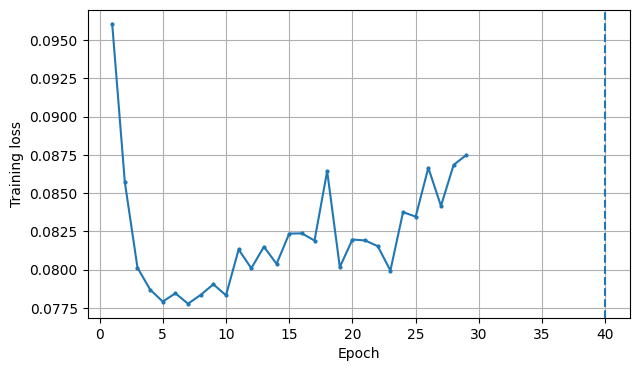

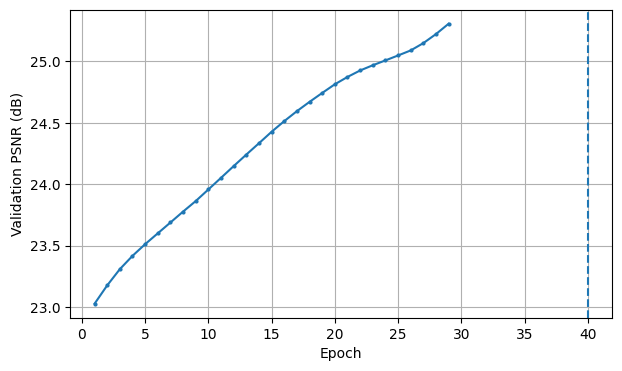

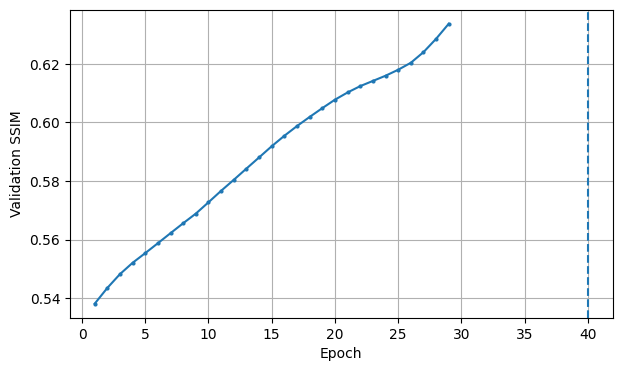

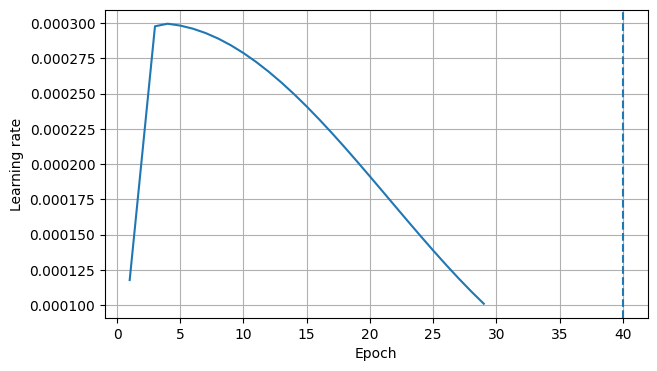

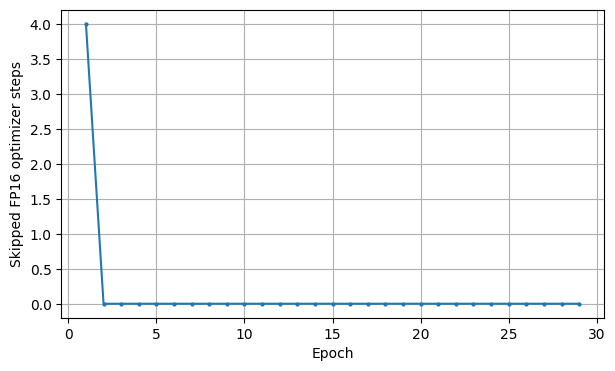

In [16]:
# CELL 17 — Plot training curves

epochs = [
    r["epoch"]
    for r in history
]

losses = [
    r["loss"]
    for r in history
]

psnrs = [
    r["psnr"]
    for r in history
]

ssims = [
    r["ssim"]
    for r in history
]

lrs = [
    r["lr"]
    for r in history
]

skips = [
    r["skipped_steps"]
    for r in history
]

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(1,1,1)
ax.plot(epochs, losses, marker="o", markersize=2)
ax.axvline(40, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.grid(True)
plt.show()

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(1,1,1)
ax.plot(epochs, psnrs, marker="o", markersize=2)
ax.axvline(40, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation PSNR (dB)")
ax.grid(True)
plt.show()

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(1,1,1)
ax.plot(epochs, ssims, marker="o", markersize=2)
ax.axvline(40, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation SSIM")
ax.grid(True)
plt.show()

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(1,1,1)
ax.plot(epochs, lrs)
ax.axvline(40, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.grid(True)
plt.show()

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(1,1,1)
ax.plot(epochs, skips, marker="o", markersize=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Skipped FP16 optimizer steps")
ax.grid(True)
plt.show()

In [17]:
# CELL 18 — Bicubic baseline

@torch.no_grad()
def evaluate_bicubic(
    loader
):

    psnr_sum = 0.0
    ssim_sum = 0.0
    count = 0

    for lr,gt in loader:

        lr = lr.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        pred = F.interpolate(
            lr.clamp(
                0,
                1
            ),
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        ).clamp(
            0,
            1
        )

        b = lr.shape[0]

        psnr_sum += (
            float(
                psnr_batch(
                    pred,
                    gt
                )
            )*b
        )

        ssim_sum += (
            float(
                ssim(
                    pred,
                    gt,
                    data_range=1.0,
                    size_average=True
                )
            )*b
        )

        count += b

    return (
        psnr_sum/count,
        ssim_sum/count
    )


bicubic_psnr,bicubic_ssim = evaluate_bicubic(
    val_loader
)

print("Bicubic PSNR:", f"{bicubic_psnr:.4f} dB")
print("Bicubic SSIM:", f"{bicubic_ssim:.6f}")

Bicubic PSNR: 22.9572 dB
Bicubic SSIM: 0.535671


In [18]:
# CELL 19 — Candidate model comparison

def load_ema_model(
    path
):

    ckpt = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    m = FastNAFSR(
        **ckpt["model_cfg"]
    )

    m.load_state_dict(
        ckpt["ema"],
        strict=True
    )

    m = m.to(
        device
    ).eval()

    return m,ckpt


candidate_paths = [
    BEST_PSNR_PATH,
    BEST_SSIM_PATH
]

for e in [
    40,
    45,
    50
]:

    p = os.path.join(
        RUN_DIR,
        f"epoch_{e:02d}.pt"
    )

    if os.path.exists(
        p
    ):

        candidate_paths.append(
            p
        )

candidate_paths = list(
    dict.fromkeys(
        candidate_paths
    )
)

quality_results = []

for path in candidate_paths:

    if not os.path.exists(
        path
    ):

        continue

    m,ckpt = load_ema_model(
        path
    )

    ps,ss = validate_fp32(
        m,
        val_loader
    )

    r = {
        "path":path,
        "name":os.path.basename(path),
        "epoch":ckpt["epoch"],
        "psnr":ps,
        "ssim":ss
    }

    quality_results.append(
        r
    )

    print(
        f"{r['name']:>16} | "
        f"epoch={r['epoch']:02d} | "
        f"PSNR={r['psnr']:.4f} | "
        f"SSIM={r['ssim']:.6f}"
    )

    del m

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    best_psnr.pt | epoch=29 | PSNR=25.3076 | SSIM=0.633729
    best_ssim.pt | epoch=29 | PSNR=25.3076 | SSIM=0.633729


In [19]:
# CELL 20 — LPIPS comparison

import lpips

lpips_net = lpips.LPIPS(
    net="alex"
).to(
    device
).eval()


@torch.no_grad()
def model_lpips(
    model,
    loader
):

    total = 0.0
    count = 0

    for lr,gt in loader:

        lr = lr.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        pred = model(
            lr
        ).clamp(
            0,
            1
        )

        pred3 = (
            pred.repeat(
                1,
                3,
                1,
                1
            )*2-1
        )

        gt3 = (
            gt.repeat(
                1,
                3,
                1,
                1
            )*2-1
        )

        d = lpips_net(
            pred3,
            gt3
        )

        b = lr.shape[0]

        total += (
            float(
                d.mean()
            )*b
        )

        count += b

    return total/count


@torch.no_grad()
def bicubic_lpips_fn(
    loader
):

    total = 0.0
    count = 0

    for lr,gt in loader:

        lr = lr.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        pred = F.interpolate(
            lr.clamp(
                0,
                1
            ),
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        ).clamp(
            0,
            1
        )

        pred3 = (
            pred.repeat(
                1,
                3,
                1,
                1
            )*2-1
        )

        gt3 = (
            gt.repeat(
                1,
                3,
                1,
                1
            )*2-1
        )

        d = lpips_net(
            pred3,
            gt3
        )

        b = lr.shape[0]

        total += (
            float(
                d.mean()
            )*b
        )

        count += b

    return total/count


bicubic_lpips = bicubic_lpips_fn(
    val_loader
)

print(
    "Bicubic LPIPS:",
    f"{bicubic_lpips:.6f}"
)

for r in quality_results:

    m,ckpt = load_ema_model(
        r["path"]
    )

    lp = model_lpips(
        m,
        val_loader
    )

    r["lpips"] = lp

    print(
        f"{r['name']:>16} | "
        f"epoch={r['epoch']:02d} | "
        f"PSNR={r['psnr']:.4f} | "
        f"SSIM={r['ssim']:.6f} | "
        f"LPIPS={lp:.6f}"
    )

    del m

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 129MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Bicubic LPIPS: 0.435001
    best_psnr.pt | epoch=29 | PSNR=25.3076 | SSIM=0.633729 | LPIPS=0.375866
    best_ssim.pt | epoch=29 | PSNR=25.3076 | SSIM=0.633729 | LPIPS=0.375866


In [20]:
# CELL 21 — Save final metrics CSV

METRICS_CSV = os.path.join(
    RUN_DIR,
    "final_metrics.csv"
)

with open(
    METRICS_CSV,
    "w",
    newline=""
) as f:

    writer = csv.writer(
        f
    )

    writer.writerow([
        "model",
        "epoch",
        "PSNR_dB",
        "SSIM",
        "LPIPS"
    ])

    writer.writerow([
        "bicubic",
        "",
        bicubic_psnr,
        bicubic_ssim,
        bicubic_lpips
    ])

    for r in quality_results:

        writer.writerow([
            r["name"],
            r["epoch"],
            r["psnr"],
            r["ssim"],
            r.get(
                "lpips",
                ""
            )
        ])

print(
    "Saved:",
    METRICS_CSV
)

Saved: /content/drive/MyDrive/KLA_Semicon_Hackathon/stable_fast_fp16_50epoch/final_metrics.csv


In [21]:
# CELL 22 — Load best PSNR model for final inference

FINAL_SOURCE_PATH = BEST_PSNR_PATH

final_model,final_ckpt = load_ema_model(
    FINAL_SOURCE_PATH
)

print(
    "Selected model:",
    os.path.basename(
        FINAL_SOURCE_PATH
    )
)

print(
    "Epoch:",
    final_ckpt["epoch"]
)

print(
    "PSNR:",
    final_ckpt["val_psnr"]
)

print(
    "SSIM:",
    final_ckpt["val_ssim"]
)

Selected model: best_psnr.pt
Epoch: 29
PSNR: 25.30758204460144
SSIM: 0.6337292402982712


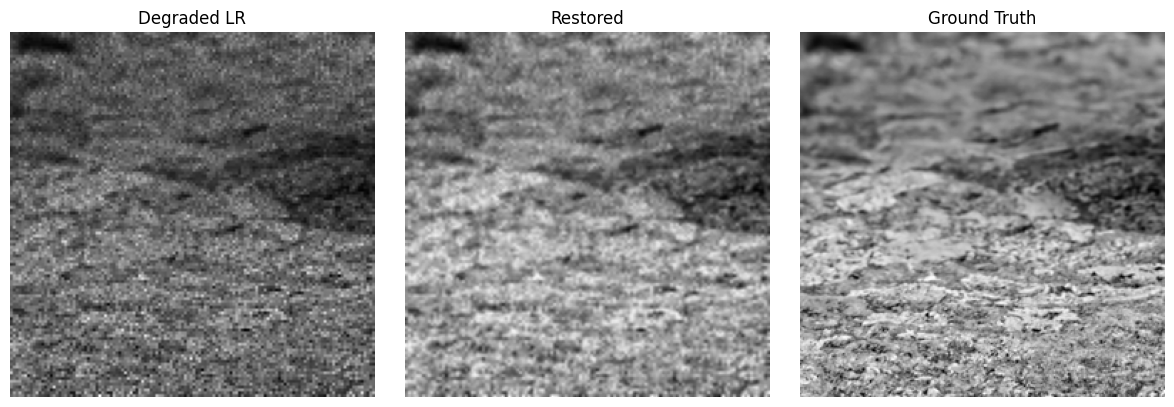

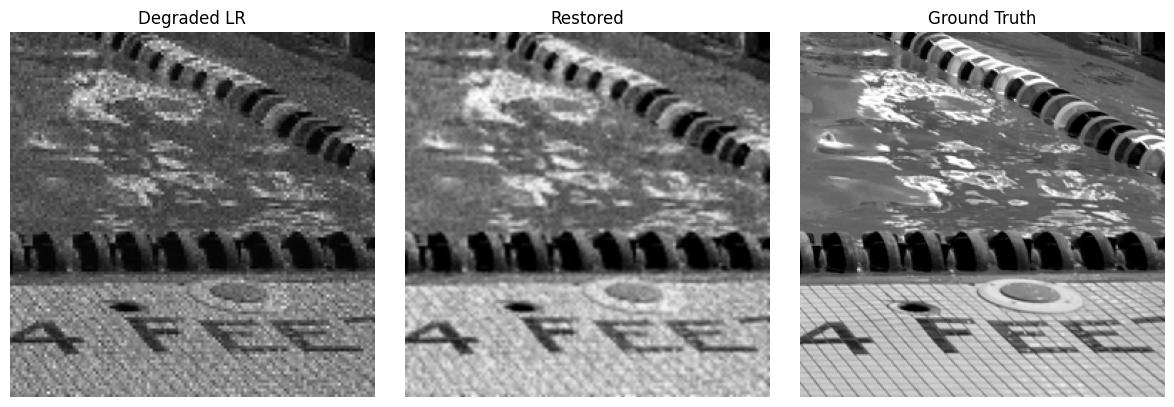

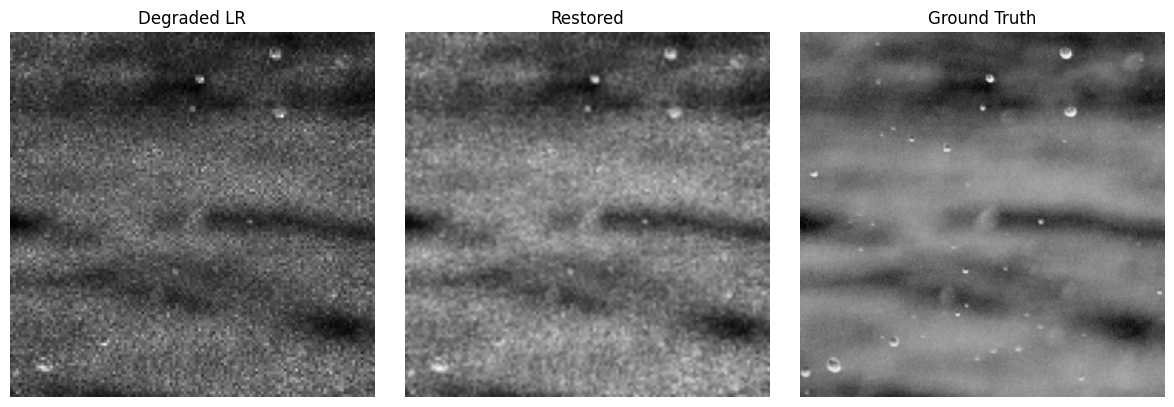

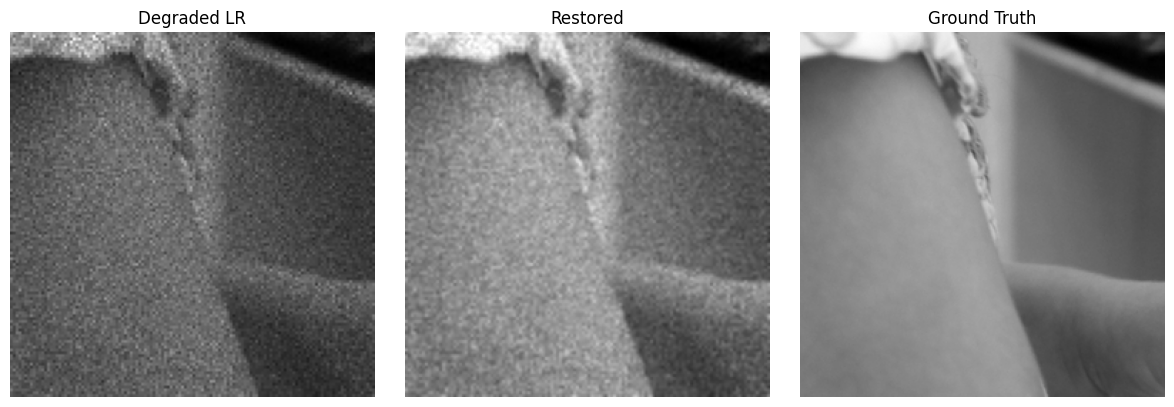

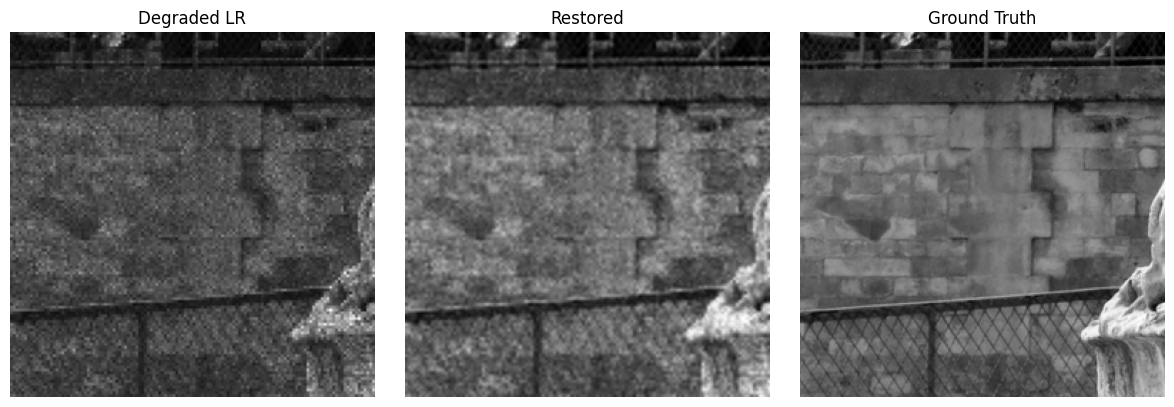

Figures saved: /content/drive/MyDrive/KLA_Semicon_Hackathon/stable_fast_fp16_50epoch/figures


In [22]:
# CELL 23 — Save validation comparison figures

FIG_DIR = os.path.join(
    RUN_DIR,
    "figures"
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

for j in range(
    5
):

    lr = np.load(
        val_lr[j],
        allow_pickle=False
    ).astype(
        np.float32
    )

    gt = np.load(
        val_gt[j],
        allow_pickle=False
    ).astype(
        np.float32
    )

    x = torch.from_numpy(
        lr
    )[None,None].to(
        device,
        dtype=torch.float32
    )

    with torch.inference_mode():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type=="cuda")
        ):

            pred = final_model(
                x
            )

    pred = (
        pred[
            0,
            0
        ]
        .float()
        .clamp(
            0,
            1
        )
        .cpu()
        .numpy()
    )

    fig = plt.figure(
        figsize=(12,4)
    )

    ax = fig.add_subplot(1,3,1)
    ax.imshow(lr,cmap="gray")
    ax.set_title("Degraded LR")
    ax.axis("off")

    ax = fig.add_subplot(1,3,2)
    ax.imshow(pred,cmap="gray",vmin=0,vmax=1)
    ax.set_title("Restored")
    ax.axis("off")

    ax = fig.add_subplot(1,3,3)
    ax.imshow(gt,cmap="gray",vmin=0,vmax=1)
    ax.set_title("Ground Truth")
    ax.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        FIG_DIR,
        f"comparison_{j:02d}.png"
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

print(
    "Figures saved:",
    FIG_DIR
)

In [23]:
# CELL 24 — FP16 inference throughput benchmark

def benchmark_inference(
    model,
    batch_size,
    warmup=10,
    repetitions=30
):

    if device.type != "cuda":

        print(
            "CUDA GPU required."
        )

        return None

    x = torch.randn(
        batch_size,
        1,
        128,
        128,
        device=device,
        dtype=torch.float32
    )

    model.eval()

    with torch.inference_mode():

        for _ in range(
            warmup
        ):

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                _ = model(
                    x
                )

        torch.cuda.synchronize()

        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        for _ in range(
            repetitions
        ):

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                _ = model(
                    x
                )

        end.record()

        torch.cuda.synchronize()

        total_ms = start.elapsed_time(
            end
        )

    ms_batch = total_ms/repetitions

    ms_image = ms_batch/batch_size

    ips = 1000.0/ms_image

    print(
        f"batch={batch_size:3d} | "
        f"ms/batch={ms_batch:.3f} | "
        f"ms/image={ms_image:.4f} | "
        f"images/s={ips:.2f}"
    )

    return {
        "batch":batch_size,
        "ms_batch":ms_batch,
        "ms_image":ms_image,
        "images_per_second":ips
    }


for b in [
    32,
    64,
    128
]:

    try:

        benchmark_inference(
            final_model,
            b
        )

    except torch.cuda.OutOfMemoryError:

        torch.cuda.empty_cache()

        print(
            "OOM at batch",
            b
        )

        break

batch= 32 | ms/batch=460.395 | ms/image=14.3874 | images/s=69.51
batch= 64 | ms/batch=1042.428 | ms/image=16.2879 | images/s=61.40
batch=128 | ms/batch=1944.937 | ms/image=15.1948 | images/s=65.81


In [ ]:
# CELL 25 — Restore all 400 test images

TEST_OUTPUT_DIR = os.path.join(
    RUN_DIR,
    "restored_test_outputs"
)

os.makedirs(
    TEST_OUTPUT_DIR,
    exist_ok=True
)

test_arrays = []

for path in test_files:

    arr = np.load(
        path,
        allow_pickle=False
    ).astype(
        np.float32,
        copy=False
    )

    test_arrays.append(
        np.ascontiguousarray(
            arr
        )
    )

test_stack = np.stack(
    test_arrays,
    axis=0
)[:,None,:,:]

print(
    "Test stack:",
    test_stack.shape
)

INFER_BATCH = 64

outputs = []

final_model.eval()

with torch.inference_mode():

    for start in range(
        0,
        len(test_stack),
        INFER_BATCH
    ):

        xb = torch.from_numpy(
            test_stack[
                start:start+INFER_BATCH
            ]
        ).to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if device.type == "cuda":

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                yb = final_model(
                    xb
                )

        else:

            yb = final_model(
                xb
            )

        yb = (
            yb[
                :,0
            ]
            .float()
            .clamp(
                0,
                1
            )
            .cpu()
            .numpy()
        )

        outputs.append(
            yb
        )

outputs = np.concatenate(
    outputs,
    axis=0
)

assert outputs.shape == (
    400,
    256,
    256
)

for i,path in enumerate(
    test_files
):

    np.save(
        os.path.join(
            TEST_OUTPUT_DIR,
            os.path.basename(
                path
            )
        ),
        outputs[i].astype(
            np.float32,
            copy=False
        ),
        allow_pickle=False
    )

print(
    "Saved 400 outputs to:"
)

print(
    TEST_OUTPUT_DIR
)

Test stack: (400, 1, 128, 128)
Saved 400 outputs to:
/content/drive/MyDrive/KLA_Semicon_Hackathon/stable_fast_fp16_50epoch/restored_test_outputs


In [ ]:
# CELL 26 — Output sanity check

from pathlib import Path

saved = sorted(
    Path(
        TEST_OUTPUT_DIR
    ).glob(
        "*.npy"
    )
)

assert len(saved) == 400

sample = np.load(
    saved[0],
    allow_pickle=False
)

print("Saved files :", len(saved))
print("Shape       :", sample.shape)
print("dtype       :", sample.dtype)
print("min/max     :", float(sample.min()), float(sample.max()))

assert sample.shape == (256,256)
assert sample.dtype == np.float32
assert np.isfinite(sample).all()

print()
print("TEST OUTPUT SANITY CHECK PASSED.")

Saved files : 400
Shape       : (256, 256)
dtype       : float32
min/max     : 0.0 1.0

TEST OUTPUT SANITY CHECK PASSED.


In [25]:
# CELL 27 — final checkpoint

import shutil

FINAL_MODEL_PATH = os.path.join(
    RUN_DIR,
    "best_model.pt"
)

shutil.copy2(
    FINAL_SOURCE_PATH,
    FINAL_MODEL_PATH
)

print(
    "Final checkpoint:"
)

print(
    FINAL_MODEL_PATH
)

Final checkpoint:
/content/drive/MyDrive/KLA_Semicon_Hackathon/stable_fast_fp16_50epoch/best_model.pt
